# Comparative Analysis 
## Domain 3: The Travelling Salesman Problem (Permutation Space)

This notebook executes a head-to-head comparative analysis between the Bat Algorithm (BA) and a Genetic Algorithm (GA) in solving the classic `berlin52` Travelling Salesman Problem. Because TSP requires a strict continuous loop without visiting the same city twice, it exists in a **Permutation Space**.

### 1. Configurations
All hyperparameters are centralized here to allow for rapid experimental tuning without altering the underlying algorithmic architecture.

In [2]:

import math
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# --- GLOBAL EXPERIMENT SETTINGS ---
FILE_PATH = 'berlin52.tsp'
POPULATION_SIZE = 200       
MAX_GENERATIONS = 500       

# --- BAT ALGORITHM HYPERPARAMETERS ---
BA_A0 = 0.9                 # Initial Loudness
BA_R0 = 0.1                 # Initial Pulse Rate
BA_FMIN = 0.0               # Minimum Frequency
BA_FMAX = 0.7               # Maximum Frequency

# --- GENETIC ALGORITHM HYPERPARAMETERS ---
GA_MUTATION_RATE = 0.2      # Probability of a swap mutation occurring

# --- ROBUSTNESS TEST SETTINGS ---
TEST_RUNS = 10              # Number of independent runs for the Boxplot test
TEST_POPULATION = 50        # Smaller population for faster multi-runs
TEST_GENERATIONS = 150      # Fewer generations for faster multi-runs

### 2. The Environment and Objective Function
We dynamically parse the standard TSPLIB `berlin52.tsp` dataset. The objective function is strictly **Minimization**, calculating the total 2D Euclidean distance required to complete the closed loop.

In [3]:
# DATASET PARSER & OBJECTIVE FUNCTION
def load_tsp_file(filepath):
    """Parses a standard TSPLIB format file and extracts the coordinates."""
    coords = {}
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Could not find '{filepath}'. Ensure it is in the same folder as this notebook.")
        
    with open(filepath, 'r') as f:
        lines = f.readlines()
        
    reading_coords = False
    for line in lines:
        line = line.strip()
        if line == "NODE_COORD_SECTION":
            reading_coords = True
            continue
        if line == "EOF" or not line:
            break
        if reading_coords:
            parts = line.split()
            if len(parts) >= 3:
                node_id = int(parts[0])
                coords[node_id] = (float(parts[1]), float(parts[2]))
                
    return coords

# Load the file dynamically using config
berlin52_coords = load_tsp_file(FILE_PATH)

def calculate_distance(route, coords):
    """Calculates the total Euclidean distance of a given routing sequence."""
    dist = 0.0
    for i in range(len(route)):
        city_a = route[i]
        city_b = route[(i + 1) % len(route)] # Wrap around to close the loop
        x1, y1 = coords[city_a]
        x2, y2 = coords[city_b]
        dist += math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    return dist

print(f"Successfully loaded {len(berlin52_coords)} cities from '{FILE_PATH}'.")

Successfully loaded 52 cities from 'berlin52.tsp'.


### 3. Velocity as Swap Sequences
The native Bat Algorithm calculates velocity as a continuous floating-point number. To force bats to fly through a sequence of cities, we redefine Velocity as an array of swap operations. 
* **Target Velocity:** Calculated by subtracting the current route from the target route to find the exact swaps needed to match the leader.
* **Momentum (Frequency):** Acts as a scalar. A higher frequency allows the bat to execute more of the required swaps, pushing it closer to the global best position.

In [4]:
# SWAP LOGIC
def subtract_routes(target_route, current_route):
    """Calculates 'velocity' (the sequence of swaps) needed to reach the target."""
    swaps = []
    temp_route = current_route.copy()
    for i in range(len(target_route)):
        if temp_route[i] != target_route[i]:
            target_city = target_route[i]
            target_idx = temp_route.index(target_city)
            swaps.append((i, target_idx))
            temp_route[i], temp_route[target_idx] = temp_route[target_idx], temp_route[i]
    return swaps

def multiply_velocity(swaps, scalar):
    """Applies momentum or frequency. Scalar reduces the number of swaps."""
    scalar = max(0.0, min(1.0, abs(scalar))) 
    num_to_keep = int(len(swaps) * scalar)
    if num_to_keep == 0:
        return []
    return random.sample(swaps, num_to_keep)

def add_velocity(route, swaps):
    """Applies the velocity (swaps) to the physical route."""
    new_route = route.copy()
    for swap in swaps:
        idx1, idx2 = swap
        new_route[idx1], new_route[idx2] = new_route[idx2], new_route[idx1]
    return new_route


### 4. The Permutation Bat Agent
The agent retains the biological parameters of the standard Bat Algorithm but is adapted for routing. The Local Search phase ("The Hunt") executes a 2-opt style swap—randomly flipping the position of two cities to escape local minima.

In [5]:
#  THE PERMUTATION BAT AGENT
class PermutationBat:
    def __init__(self, cities_list):
        self.route = random.sample(cities_list, len(cities_list))
        self.velocity = [] 
        self.fitness = float('inf')
        self.A = BA_A0
        self.r = BA_R0
        self.r0 = BA_R0
        self.fmin = BA_FMIN
        self.fmax = BA_FMAX
        self.f = 0.0
        
    def update_frequency(self):
        self.f = self.fmin + (self.fmax - self.fmin) * random.random()

    def local_search(self, global_best_route):
        """The Hunt: Randomly flip two cities to break out of routing gridlocks."""
        new_route = global_best_route.copy()
        idx1, idx2 = random.sample(range(len(new_route)), 2)
        new_route[idx1], new_route[idx2] = new_route[idx2], new_route[idx1]
        return new_route
        
    def update_parameters(self, iteration, alpha=0.9, gamma=0.05):
        self.A = alpha * self.A
        self.r = self.r0 * (1 - math.exp(-gamma * iteration))


### 5. Bat Algorithm Execution
The swarm navigates the permutation space. The acceptance criteria strictly requires the new route to be shorter than or equal to the current route (`<=`), while checking if the bat's loudness (`A`) permits the update.

In [6]:
# TSP BAT ALGORITHM
def ba_tsp(cities_dict, num_bats, max_iterations):
    cities_list = list(cities_dict.keys())
    swarm = [PermutationBat(cities_list) for _ in range(num_bats)]
    
    global_best_route = None
    global_best_distance = float('inf')
    logbook = []
    
    for bat in swarm:
        bat.fitness = calculate_distance(bat.route, cities_dict)
        if bat.fitness < global_best_distance:
            global_best_distance = bat.fitness
            global_best_route = bat.route.copy()
            
    for t in range(max_iterations):
        gen_start_time = time.time()
        current_swarm_fitness = []
        
        for bat in swarm:
            bat.update_frequency()
            
            # Flight Math via Swap Sequence
            velocity_update = subtract_routes(global_best_route, bat.route)
            bat.velocity = multiply_velocity(velocity_update, bat.f)
            new_route = add_velocity(bat.route, bat.velocity)
            
            if random.random() > bat.r:
                new_route = bat.local_search(global_best_route)
                
            new_fitness = calculate_distance(new_route, cities_dict)
            
            if new_fitness <= bat.fitness and random.random() < bat.A:
                bat.route = new_route.copy()
                bat.fitness = new_fitness
                bat.update_parameters(t)
                
            if bat.fitness < global_best_distance:
                global_best_distance = bat.fitness
                global_best_route = bat.route.copy()
                
            current_swarm_fitness.append(bat.fitness)

        gen_exec_time = time.time() - gen_start_time
        current_avg = sum(current_swarm_fitness) / num_bats
        
        logbook.append({
            "gen": t,
            "nevals": num_bats,
            "exec_time_seconds": round(gen_exec_time, 6),
            "min": round(global_best_distance, 2),
            "avg": round(current_avg, 2)
        })

    return global_best_route, global_best_distance, pd.DataFrame(logbook)

### 6. Genetic Algorithm Baseline
The control group utilizes standard evolutionary operators adapted for routing:
* **Order Crossover (OX1):** Ensures that offspring inherit partial valid sequences from parents without duplicating cities.
* **Swap Mutation:** Randomly flips two cities to maintain genetic diversity.

In [7]:
# TSP GENETIC ALGORITHM 
def ga_tsp(cities_dict, pop_size, max_iterations):
    cities_list = list(cities_dict.keys())
    population = [random.sample(cities_list, len(cities_list)) for _ in range(pop_size)]
    
    global_best_route = None
    global_best_distance = float('inf')
    logbook = []

    for t in range(max_iterations):
        gen_start_time = time.time()
        
        pop_fitness = [(ind, calculate_distance(ind, cities_dict)) for ind in population]
        pop_fitness.sort(key=lambda x: x[1]) 
        
        current_min = pop_fitness[0][1]
        current_avg = sum(f for _, f in pop_fitness) / pop_size
        
        if current_min < global_best_distance:
            global_best_distance = current_min
            global_best_route = pop_fitness[0][0].copy()
            
        next_gen = [pop_fitness[0][0], pop_fitness[1][0]] 
        
        while len(next_gen) < pop_size:
            p1 = min(random.sample(pop_fitness, 3), key=lambda x: x[1])[0]
            p2 = min(random.sample(pop_fitness, 3), key=lambda x: x[1])[0]
            
            # Order Crossover (OX1)
            start, end = sorted(random.sample(range(len(p1)), 2))
            child = [-1] * len(p1)
            child[start:end] = p1[start:end]
            
            p2_filtered = [city for city in p2 if city not in child]
            ptr = 0
            for i in range(len(child)):
                if child[i] == -1:
                    child[i] = p2_filtered[ptr]
                    ptr += 1
            
            if random.random() < GA_MUTATION_RATE:
                idx1, idx2 = random.sample(range(len(child)), 2)
                child[idx1], child[idx2] = child[idx2], child[idx1]
                
            next_gen.append(child)
            
        population = next_gen
        gen_exec_time = time.time() - gen_start_time
        
        logbook.append({
            "gen": t,
            "nevals": pop_size,
            "exec_time_seconds": round(gen_exec_time, 6),
            "min": round(current_min, 2),
            "avg": round(current_avg, 2)
        })

    return global_best_route, global_best_distance, pd.DataFrame(logbook)

### 7. Statistical Showdown and Geographic Mapping
Both algorithms are executed under identical population and generation constraints. The outcomes are compared via execution time, convergence speed, and a direct visual rendering of the final geographic routes.

 Berlin52 TSP Run (Pop: 200, Gen: 500)...

  BAT ALGORITHM RESULTS==
0 - Best Dist: 18548.88 - Avg Dist: 23098.80 - Time: 0.0166s
1 - Best Dist: 17053.92 - Avg Dist: 19487.32 - Time: 0.0110s
2 - Best Dist: 16763.88 - Avg Dist: 18201.47 - Time: 0.0110s
3 - Best Dist: 15954.72 - Avg Dist: 17436.98 - Time: 0.0096s
4 - Best Dist: 15521.33 - Avg Dist: 16820.02 - Time: 0.0087s
5 - Best Dist: 13967.54 - Avg Dist: 16220.74 - Time: 0.0090s
6 - Best Dist: 13792.30 - Avg Dist: 15453.93 - Time: 0.0100s
7 - Best Dist: 13740.71 - Avg Dist: 14997.49 - Time: 0.0105s
8 - Best Dist: 13673.01 - Avg Dist: 14712.78 - Time: 0.0085s
9 - Best Dist: 13258.12 - Avg Dist: 14430.83 - Time: 0.0086s
10 - Best Dist: 13236.69 - Avg Dist: 14206.43 - Time: 0.0090s
11 - Best Dist: 12922.82 - Avg Dist: 14081.19 - Time: 0.0080s
12 - Best Dist: 12922.82 - Avg Dist: 13844.00 - Time: 0.0090s
13 - Best Dist: 12826.38 - Avg Dist: 13708.07 - Time: 0.0090s
14 - Best Dist: 12535.95 - Avg Dist: 13557.35 - Time: 0.0090s

Best Route

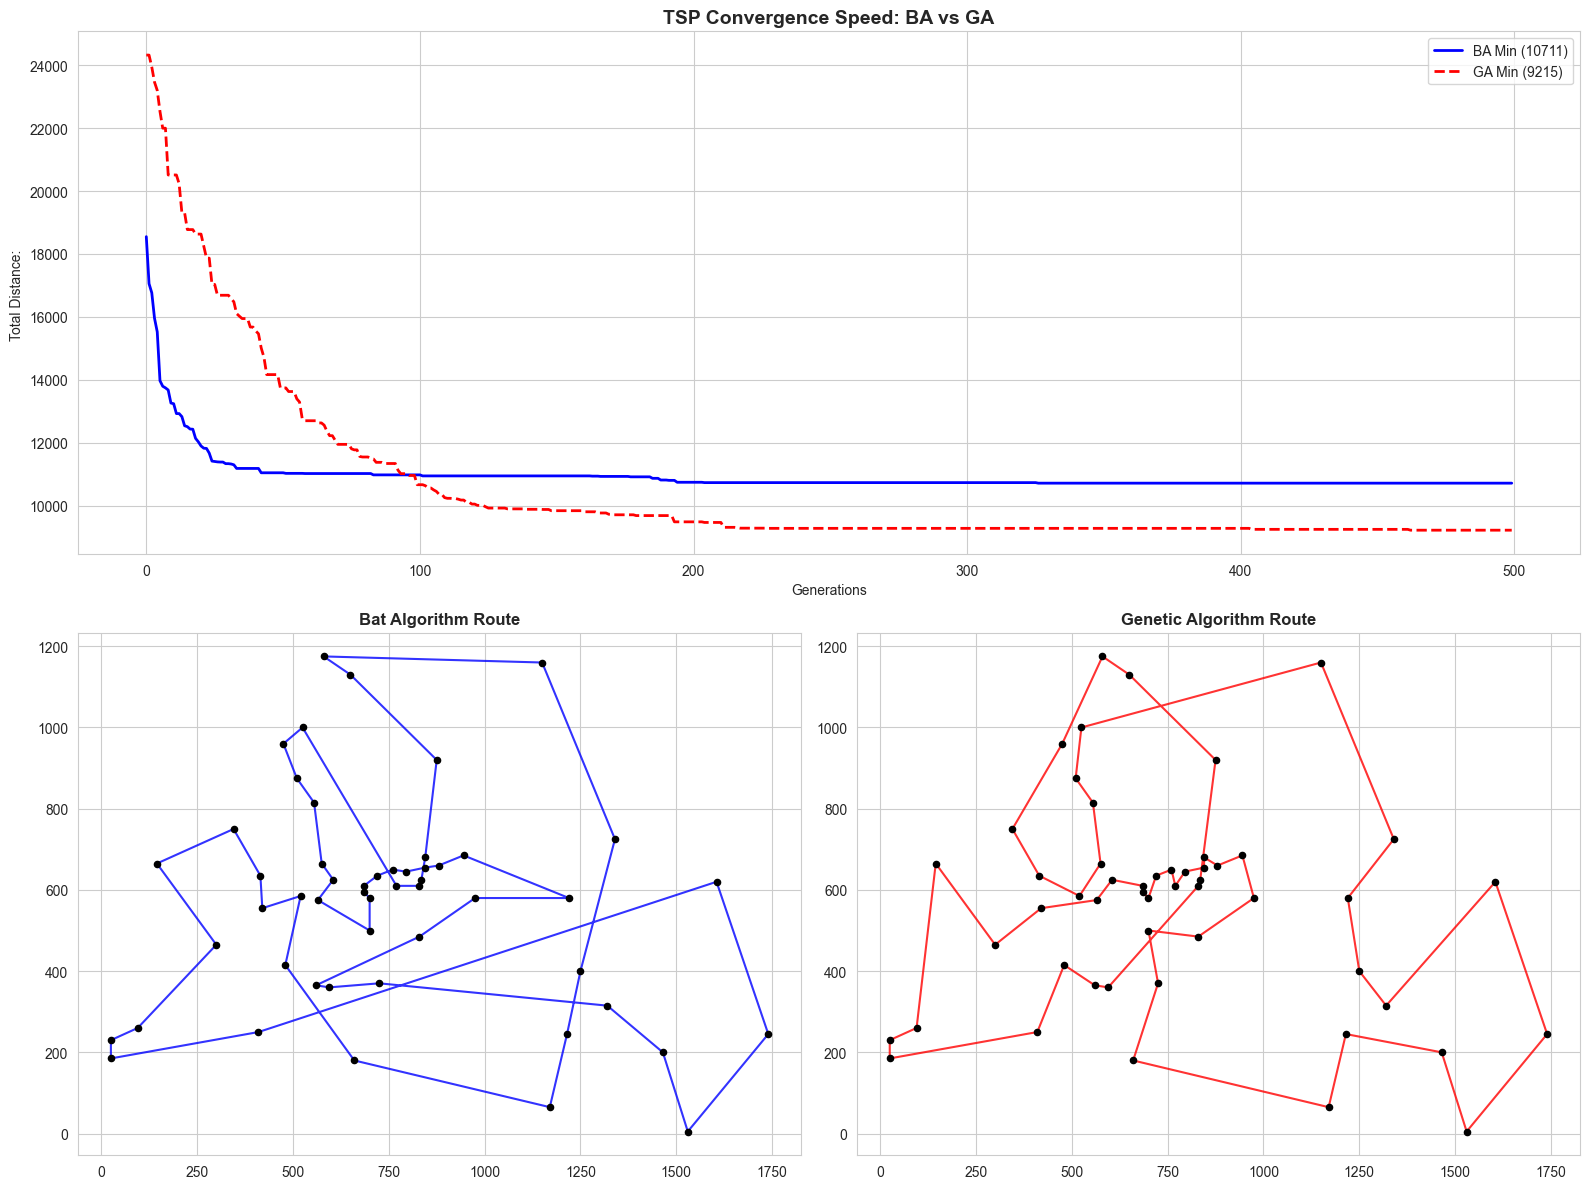

In [8]:
# TSP Run
print(f" Berlin52 TSP Run (Pop: {POPULATION_SIZE}, Gen: {MAX_GENERATIONS})...\n")

ba_route, ba_dist, ba_log = ba_tsp(berlin52_coords, POPULATION_SIZE, MAX_GENERATIONS)
ga_route, ga_dist, ga_log = ga_tsp(berlin52_coords, POPULATION_SIZE, MAX_GENERATIONS)

print("  BAT ALGORITHM RESULTS==")
for index, row in ba_log.head(15).iterrows():
    print(f"{int(row['gen'])} - Best Dist: {row['min']:.2f} - Avg Dist: {row['avg']:.2f} - Time: {row['exec_time_seconds']:.4f}s")
print(f"\nBest Route (Distance: {ba_dist:.2f}):\n{ba_route}\n")

print("GENETIC ALGORITHM RESULTS==")
for index, row in ga_log.head(15).iterrows():
    print(f"{int(row['gen'])} - Best Dist: {row['min']:.2f} - Avg Dist: {row['avg']:.2f} - Time: {row['exec_time_seconds']:.4f}s")
print(f"\nBest Route (Distance: {ga_dist:.2f}):\n{ga_route}\n\n")

ba_total_time = ba_log['exec_time_seconds'].sum()
ba_avg_time = ba_log['exec_time_seconds'].mean()
ga_total_time = ga_log['exec_time_seconds'].sum()
ga_avg_time = ga_log['exec_time_seconds'].mean()

table_data = [
    ["Algorithm", "Population", "Generations", "Final Min Distance", "Final Avg Distance", "Total Time (s)", "Avg Gen Time (s)"],
    ["Bat Algorithm", POPULATION_SIZE, MAX_GENERATIONS, f"{ba_dist:.2f}", f"{ba_log['avg'].iloc[-1]:.2f}", f"{ba_total_time:.4f}", f"{ba_avg_time:.6f}"],
    ["Genetic Algorithm", POPULATION_SIZE, MAX_GENERATIONS, f"{ga_dist:.2f}", f"{ga_log['avg'].iloc[-1]:.2f}", f"{ga_total_time:.4f}", f"{ga_avg_time:.6f}"]
]
print("--- ALGORITHM PERFORMANCE SUMMARY ---")
print(tabulate(table_data, headers='firstrow', tablefmt='fancy_grid'))
print("\n")

sns.set_style("whitegrid")
fig = plt.figure(figsize=(16, 12))

ax1 = plt.subplot(2, 1, 1)
ax1.plot(ba_log['gen'], ba_log['min'], color='blue', linewidth=2, label=f'BA Min ({ba_dist:.0f})')
ax1.plot(ga_log['gen'], ga_log['min'], color='red', linestyle='dashed', linewidth=2, label=f'GA Min ({ga_dist:.0f})')
ax1.set_title("TSP Convergence Speed: BA vs GA", fontsize=14, fontweight='bold')
ax1.set_xlabel("Generations")
ax1.set_ylabel("Total Distance: ")
ax1.legend()

def draw_map(ax, route, title, line_color):
    x = [berlin52_coords[c][0] for c in route] + [berlin52_coords[route[0]][0]]
    y = [berlin52_coords[c][1] for c in route] + [berlin52_coords[route[0]][1]]
    ax.plot(x, y, c=line_color, linestyle='-', linewidth=1.5, alpha=0.8)
    ax.scatter(x[:-1], y[:-1], c='black', s=20, zorder=5)
    ax.set_title(title, fontweight='bold')

ax2 = plt.subplot(2, 2, 3)
draw_map(ax2, ba_route, f"Bat Algorithm Route", 'blue')
ax3 = plt.subplot(2, 2, 4)
draw_map(ax3, ga_route, f"Genetic Algorithm Route", 'red')

plt.tight_layout()
plt.show()

### 8. Stochastic Robustness Test
Because metaheuristics rely on random number generation, a single execution is statistically insufficient. This cell executes 10 independent runs of both algorithms to evaluate their variance, reliability, and worst-case performance bounds.

--- ROBUSTNESS TEST (10 Independent Runs) ---
Using reduced parameters for speed (Pop: 50, Gen: 150)...

Executing Run 1/10...
Executing Run 2/10...
Executing Run 3/10...
Executing Run 4/10...
Executing Run 5/10...
Executing Run 6/10...
Executing Run 7/10...
Executing Run 8/10...
Executing Run 9/10...
Executing Run 10/10...

Processing statistics...

╒═══════════════════╤══════════════════╤═══════════════════╤════════════════════╤═════════════════╕
│ Algorithm         │   Best Run (Min) │   Worst Run (Max) │   Average Distance │   Std Deviation │
╞═══════════════════╪══════════════════╪═══════════════════╪════════════════════╪═════════════════╡
│ Bat Algorithm     │          11493   │             13225 │            12485.4 │          557.72 │
├───────────────────┼──────────────────┼───────────────────┼────────────────────┼─────────────────┤
│ Genetic Algorithm │          10820.8 │             13158 │            11801.3 │          731.81 │
╘═══════════════════╧══════════════════╧═══════

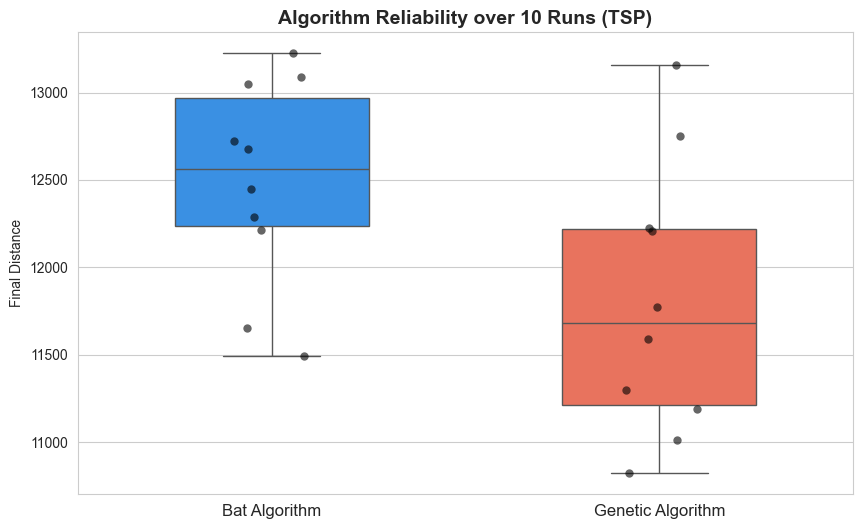

In [9]:
#Robustness Test  (TSP)
print(f"--- ROBUSTNESS TEST ({TEST_RUNS} Independent Runs) ---")
print(f"Using reduced parameters for speed (Pop: {TEST_POPULATION}, Gen: {TEST_GENERATIONS})...\n")

ba_final_dists, ga_final_dists = [], []

for i in range(TEST_RUNS):
    print(f"Executing Run {i+1}/{TEST_RUNS}...")
    _, ba_fit, _ = ba_tsp(berlin52_coords, TEST_POPULATION, TEST_GENERATIONS)
    _, ga_fit, _ = ga_tsp(berlin52_coords, TEST_POPULATION, TEST_GENERATIONS)
    ba_final_dists.append(ba_fit)
    ga_final_dists.append(ga_fit)

print("\nProcessing statistics...\n")

table_data = [
    ["Algorithm", "Best Run (Min)", "Worst Run (Max)", "Average Distance", "Std Deviation"],
    ["Bat Algorithm", f"{np.min(ba_final_dists):.2f}", f"{np.max(ba_final_dists):.2f}", f"{np.mean(ba_final_dists):.2f}", f"{np.std(ba_final_dists):.2f}"],
    ["Genetic Algorithm", f"{np.min(ga_final_dists):.2f}", f"{np.max(ga_final_dists):.2f}", f"{np.mean(ga_final_dists):.2f}", f"{np.std(ga_final_dists):.2f}"]
]
print(tabulate(table_data, headers='firstrow', tablefmt='fancy_grid'))

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.boxplot(data=[ba_final_dists, ga_final_dists], palette=['dodgerblue', 'tomato'], width=0.5)
sns.stripplot(data=[ba_final_dists, ga_final_dists], color='black', alpha=0.6, jitter=True, size=6)
plt.title(f"Algorithm Reliability over {TEST_RUNS} Runs (TSP)", fontsize=14, fontweight='bold')
plt.ylabel("Final Distance")
plt.xticks([0, 1], ['Bat Algorithm', 'Genetic Algorithm'], fontsize=12)
plt.show()

C:\Users\parsa\AppData\Local\Temp\ipykernel_15584\4036241314.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=labels, patch_artist=True, widths=0.3,


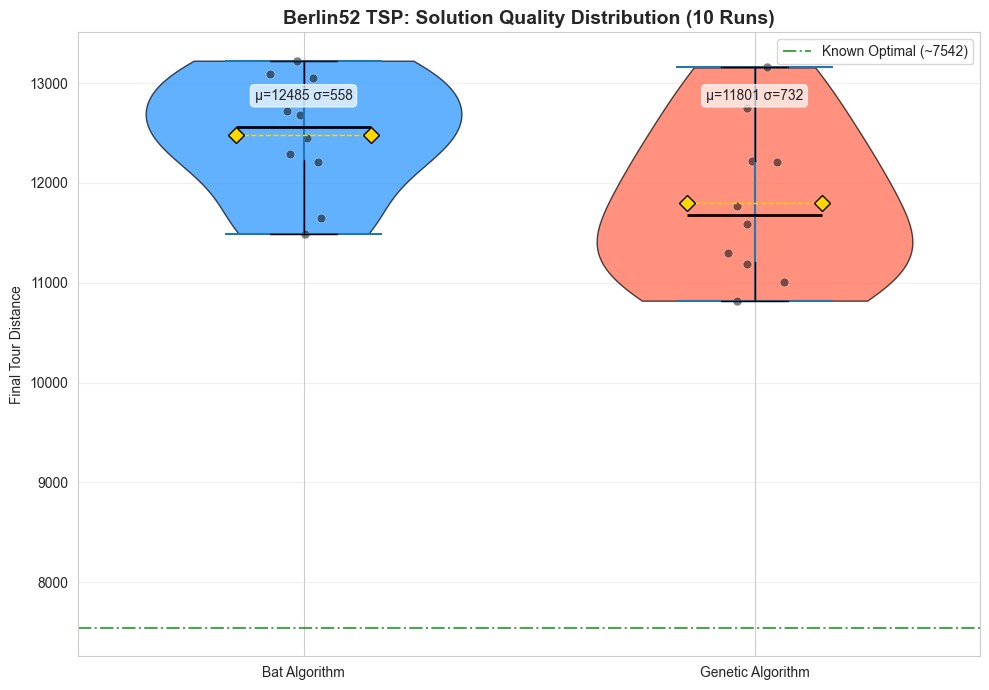

' Wider sections = more runs found solutions at that distance\nBlack dots = individual run results\nYellow diamonds = mean values Solutions range from ~10,500 to ~14,000\nLarge standard deviations show high variability'

In [10]:
#test visualization
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
plt.figure(figsize=(10, 7))

data = [ba_final_dists, ga_final_dists]
labels = ['Bat Algorithm', 'Genetic Algorithm']

# Violin plot (shows distribution shape)
vp = plt.violinplot(data, showmeans=False, showmedians=False, widths=0.7)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(['dodgerblue', 'tomato'][i])
    body.set_alpha(0.7)
    body.set_edgecolor('black')

# Overlay boxplot for stats
bp = plt.boxplot(data, labels=labels, patch_artist=True, widths=0.3, 
                 showmeans=True, meanline=True,
                 meanprops=dict(color='gold', marker='D', markersize=8, markerfacecolor='gold', markeredgecolor='black'),
                 medianprops=dict(color='black', linewidth=2),
                 boxprops=dict(alpha=0))

# Add individual points (jittered)
for i, dists in enumerate(data, 1):
    y = np.random.normal(i, 0.04, size=len(dists))
    plt.scatter(y, dists, color='black', alpha=0.5, s=40, edgecolors='white', linewidth=0.5)

# Reference line: Known optimal
optimal_berlin52 = 7542
plt.axhline(y=optimal_berlin52, color='green', linestyle='-.', linewidth=1.5, alpha=0.7, label=f'Known Optimal (~{optimal_berlin52})')

plt.title(f"Berlin52 TSP: Solution Quality Distribution ({TEST_RUNS} Runs)", fontsize=14, fontweight='bold')
plt.ylabel("Final Tour Distance")
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3, axis='y')

# Add stats text
for i, (label, dists) in enumerate(zip(labels, data), 1):
    plt.text(i, plt.ylim()[1]*0.95, f'μ={np.mean(dists):.0f} σ={np.std(dists):.0f}', 
             ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('tsp_robustness_violin.png', dpi=300, bbox_inches='tight')
plt.show()
''' Wider sections = more runs found solutions at that distance
Black dots = individual run results
Yellow diamonds = mean values Solutions range from ~10,500 to ~14,000
Large standard deviations show high variability'''
